   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  
5        2  
6        2  
7        2  
8        2  
9        2  


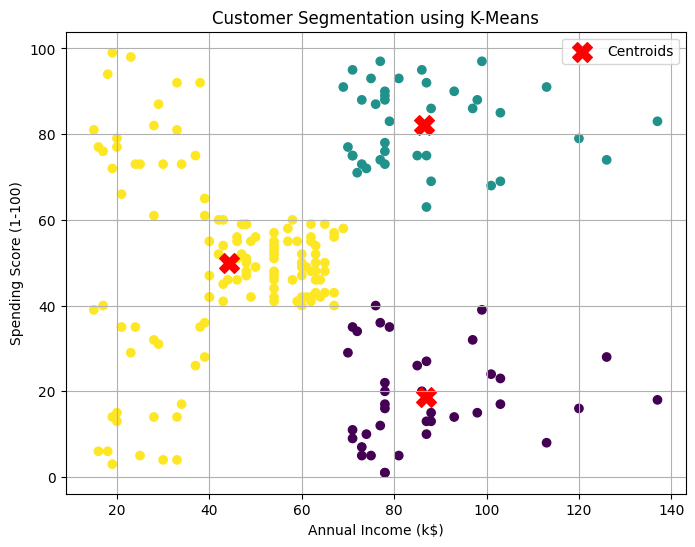

In [1]:
# Apply K-Means clustering (from sklearn.cluster) to segment customers into 3 groups based on Annual Income and Spending Score, then add a new column 'Cluster' to your DataFrame with the assigned cluster for each customer.<br><br><em><strong>Constraint:</strong> Use only the two features for clustering, and set random_state=42 for reproducibility.</em>

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Apply KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

# Display first 10 rows
print(df.head(10))

# Plot Clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

# Plot Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.grid(True)

plt.show()